# Director Skill Sets Table 7 - Deaths only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm = pd.read_pickle(rf"{import_folder_path}\Director Level_FF3_CAR.pkl")
dirFirm = dirFirm.loc[ dirFirm["date_source"] == "Date of Demise"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")

# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [4]:
dirFirm

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

In [5]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log(dirFirm["CompCountOtherPastTotalAB"] + 1).astype("float")

In [6]:
dirFirm.describe()

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_SMB,OLS120_HML,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_SMB,OLS150_HML,OLS150_r_squared,OLS150_adjusted_r_squared,OLS15

# PSM

## Verifying and removing those rows with no control data points

In [7]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
dirFirm.columns.to_list()

['index',
 'Symbol',
 'Company',
 'AsOnDate',
 'AsOnYear',
 'ISIN',
 'Person Code',
 'Director Salutation',
 'Director First Name',
 'Director Middle Name',
 'Director Surname',
 'Date of Birth',
 'Gender',
 'Nationality',
 'Member of Civil Services',
 'Promoter Director (Yes/No)',
 'Position on Board',
 'Independent (Yes/No)',
 'Education1',
 'Education2',
 'Education3',
 'Education4',
 'Education5',
 'Education6',
 'Education7',
 'Education8',
 'Education9',
 'Education10',
 'Skills/Competencies',
 'Occupation',
 'Cessation Reason',
 'Other Directorship 1',
 'Other Directorship 2',
 'Other Directorship 3',
 'Other Directorship 4',
 'Other Directorship 5',
 'Other Directorship 6',
 'Other Directorship 7',
 'Other Directorship 8',
 'Other Directorship 9',
 'Other Directorship 10',
 'Other Directorship 11',
 'Other Directorship 12',
 'Other Directorship 13',
 'Other Directorship 14',
 'Other Directorship 15',
 'Brief Profile',
 'Tenure Valid till',
 'Date of Demise',
 'Indep',
 'Appoint

In [8]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


# dirFirm["NIC_2digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:2])
# dirFirm["NIC_2digit"] = dirFirm["NIC_2digit"]

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013)].copy()
# \
# & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
#psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
#psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count          349.000000             349.000000
mean            -0.003842              -0.004388
std              0.052495               0.054103
min             -0.121708              -0.232415
25%             -0.040410              -0.040410
50%             -0.009207              -0.009207
75%              0.023723               0.023723
max              0.236431               0.236431


Top values and their count:  nonwinsorised_120CAR3
0.112469    1
0.119812    1
0.136804    1
0.138262    1
0.140327    1
0.147793    1
0.156184    1
0.160253    1
0.212454    1
0.236431    1
Name: count, dtype: int64





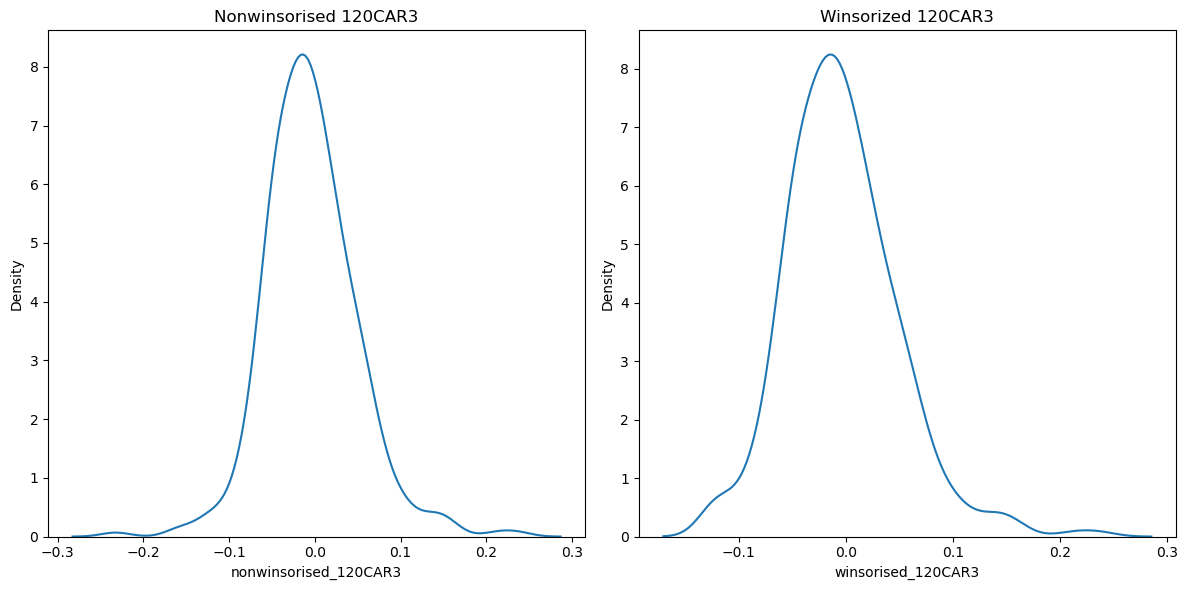

       winsorised_120CAR5  nonwinsorised_120CAR5
count          349.000000             349.000000
mean            -0.049884              -0.050470
std              0.069651               0.071106
min             -0.196124              -0.272763
25%             -0.087213              -0.087213
50%             -0.054308              -0.054308
75%             -0.020028              -0.020028
max              0.286065               0.286065


Top values and their count:  nonwinsorised_120CAR5
0.114878    1
0.115764    1
0.118346    1
0.120165    1
0.183464    1
0.187056    1
0.192421    1
0.192466    1
0.195469    1
0.286065    1
Name: count, dtype: int64





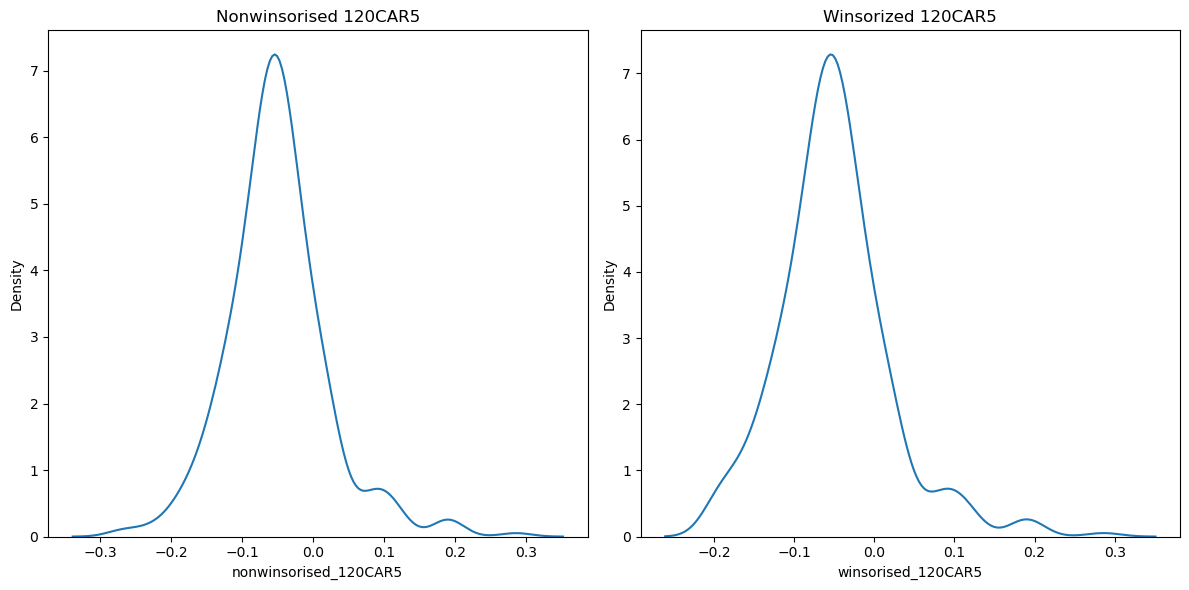

       winsorised_120CAR7  nonwinsorised_120CAR7
count          349.000000             349.000000
mean            -0.101629              -0.102229
std              0.092347               0.093942
min             -0.317956              -0.410391
25%             -0.150228              -0.150228
50%             -0.104649              -0.104649
75%             -0.059944              -0.059944
max              0.610291               0.610291


Top values and their count:  nonwinsorised_120CAR7
0.081356    1
0.100925    1
0.107261    1
0.107886    1
0.108010    1
0.112937    1
0.114679    1
0.216088    1
0.390927    1
0.610291    1
Name: count, dtype: int64





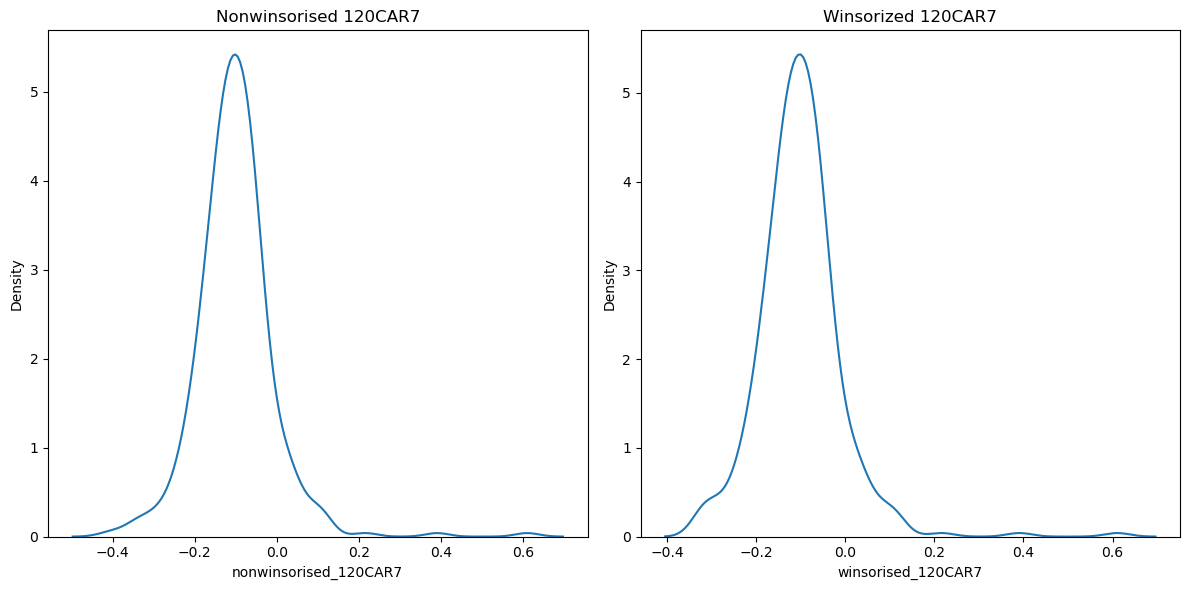

       winsorised_120CAR11  nonwinsorised_120CAR11
count           349.000000              349.000000
mean             -0.199985               -0.200800
std               0.118414                0.120768
min              -0.507256               -0.609713
25%              -0.264455               -0.264455
50%              -0.198495               -0.198495
75%              -0.135575               -0.135575
max               0.389640                0.389640


Top values and their count:  nonwinsorised_120CAR11
0.050315    1
0.053621    1
0.067729    1
0.080623    1
0.094590    1
0.101039    1
0.112172    1
0.173208    1
0.241004    1
0.389640    1
Name: count, dtype: int64





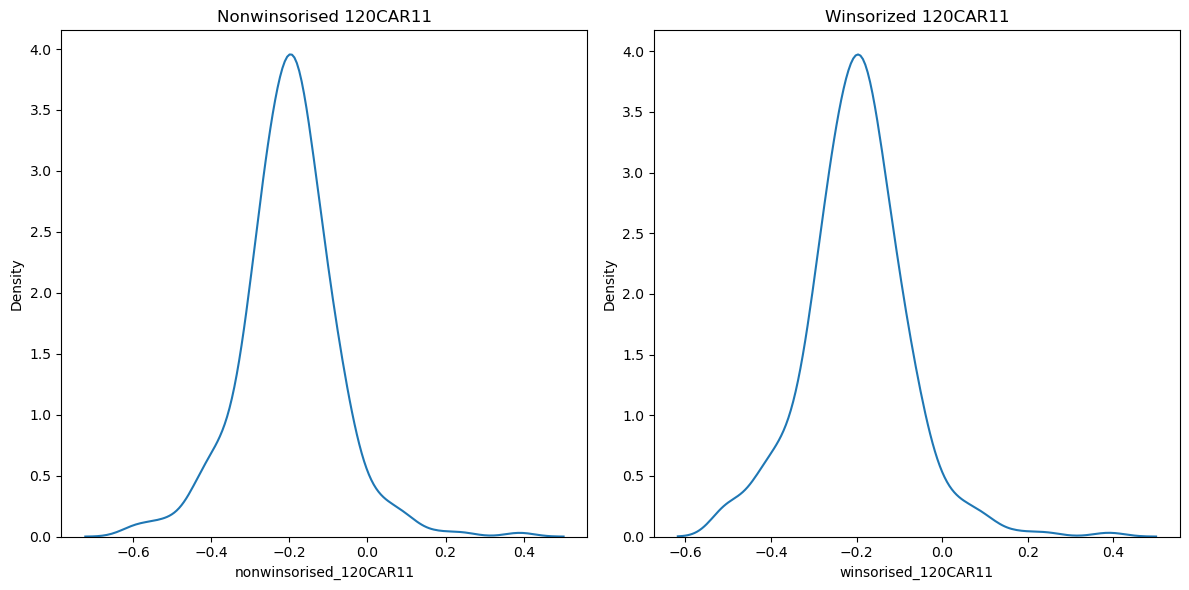

       winsorised_150CAR3  nonwinsorised_150CAR3
count          349.000000             349.000000
mean            -0.003634              -0.004184
std              0.051776               0.053371
min             -0.118398              -0.223836
25%             -0.037534              -0.037534
50%             -0.009601              -0.009601
75%              0.025704               0.025704
max              0.244325               0.244325


Top values and their count:  nonwinsorised_150CAR3
0.108982    1
0.112987    1
0.117530    1
0.135378    1
0.143986    1
0.150070    1
0.156255    1
0.156867    1
0.220575    1
0.244325    1
Name: count, dtype: int64





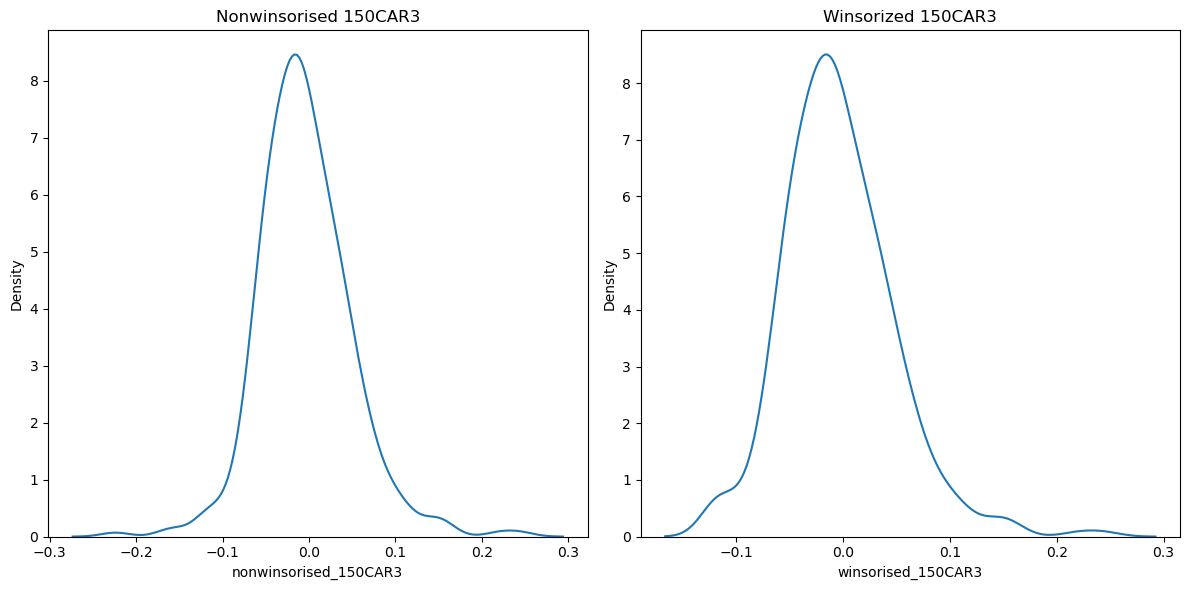

       winsorised_150CAR5  nonwinsorised_150CAR5
count          349.000000             349.000000
mean            -0.049494              -0.050175
std              0.068275               0.070012
min             -0.191810              -0.287026
25%             -0.087395              -0.087395
50%             -0.053013              -0.053013
75%             -0.017344              -0.017344
max              0.257348               0.257348


Top values and their count:  nonwinsorised_150CAR5
0.108732    1
0.109148    1
0.119580    1
0.126315    1
0.177685    1
0.191895    1
0.195254    1
0.196503    1
0.198505    1
0.257348    1
Name: count, dtype: int64





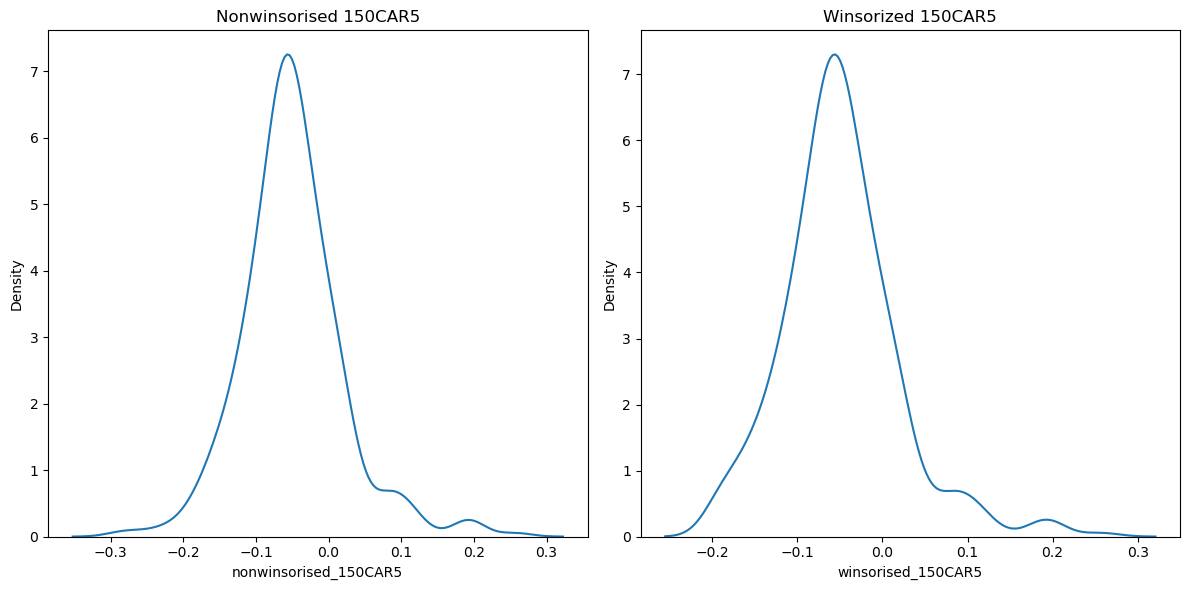

       winsorised_150CAR7  nonwinsorised_150CAR7
count          349.000000             349.000000
mean            -0.100943              -0.101725
std              0.091061               0.093146
min             -0.312158              -0.409436
25%             -0.149562              -0.149562
50%             -0.102097              -0.102097
75%             -0.059214              -0.059214
max              0.587675               0.587675


Top values and their count:  nonwinsorised_150CAR7
0.093402    1
0.095520    1
0.096626    1
0.101341    1
0.102432    1
0.106741    1
0.112629    1
0.222842    1
0.397258    1
0.587675    1
Name: count, dtype: int64





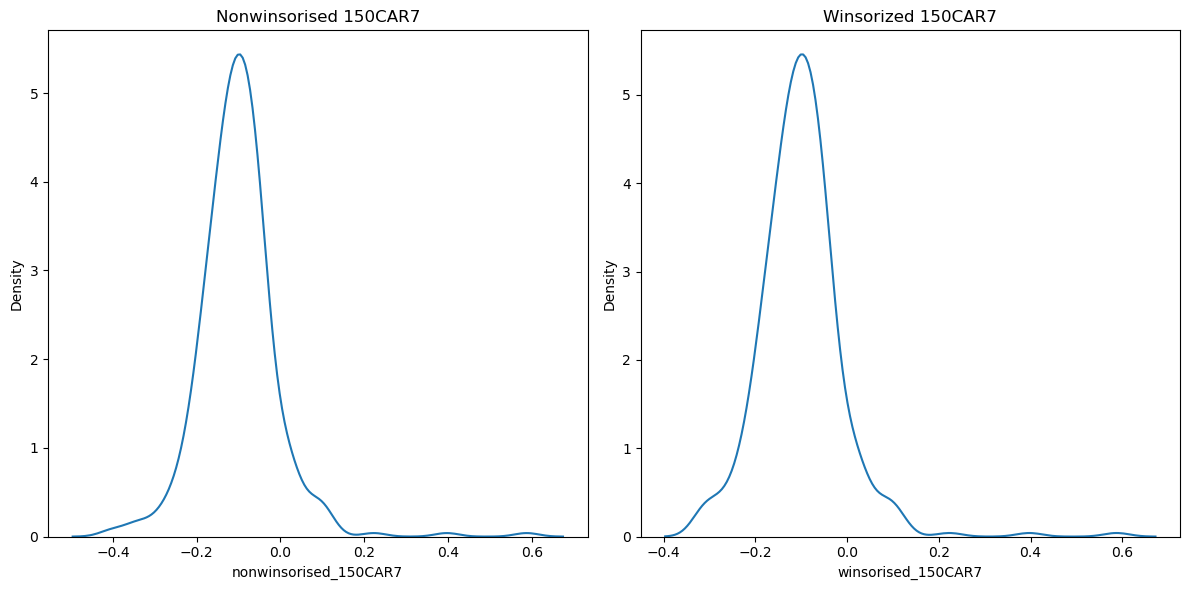

       winsorised_150CAR11  nonwinsorised_150CAR11
count           349.000000              349.000000
mean             -0.198780               -0.199630
std               0.116848                0.119378
min              -0.506540               -0.629275
25%              -0.261685               -0.261685
50%              -0.199998               -0.199998
75%              -0.131453               -0.131453
max               0.350375                0.350375


Top values and their count:  nonwinsorised_150CAR11
0.049719    1
0.052569    1
0.077321    1
0.086509    1
0.088658    1
0.092188    1
0.107613    1
0.180530    1
0.242966    1
0.350375    1
Name: count, dtype: int64





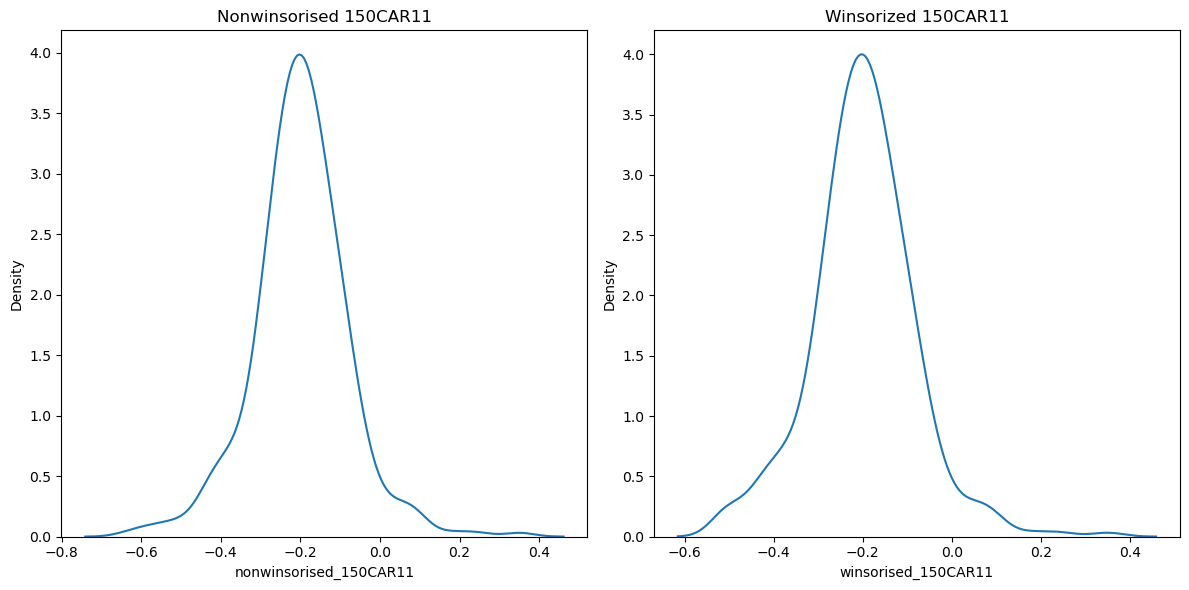

       winsorised_180CAR3  nonwinsorised_180CAR3
count          349.000000             349.000000
mean            -0.003625              -0.004163
std              0.051565               0.053120
min             -0.116329              -0.222225
25%             -0.038824              -0.038824
50%             -0.010089              -0.010089
75%              0.024491               0.024491
max              0.245356               0.245356


Top values and their count:  nonwinsorised_180CAR3
0.108719    1
0.109756    1
0.113481    1
0.136922    1
0.145636    1
0.151517    1
0.161281    1
0.165499    1
0.214598    1
0.245356    1
Name: count, dtype: int64





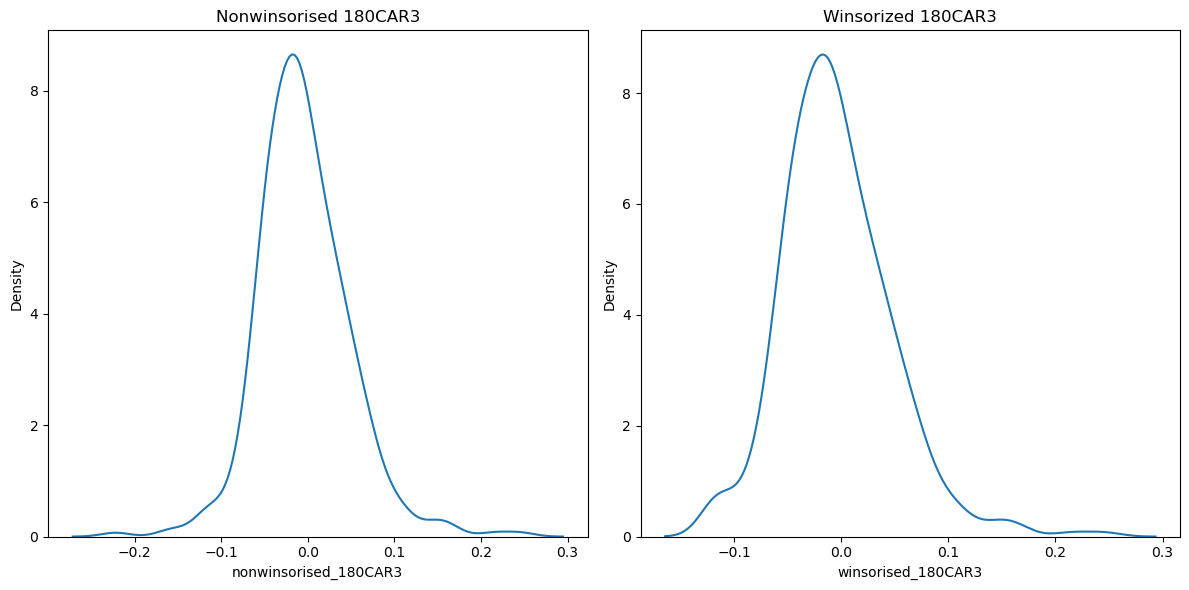

       winsorised_180CAR5  nonwinsorised_180CAR5
count          349.000000             349.000000
mean            -0.049530              -0.050244
std              0.068157               0.069944
min             -0.188161              -0.280351
25%             -0.088173              -0.088173
50%             -0.054958              -0.054958
75%             -0.018358              -0.018358
max              0.264544               0.264544


Top values and their count:  nonwinsorised_180CAR5
0.108458    1
0.115053    1
0.119322    1
0.130015    1
0.160013    1
0.193288    1
0.197180    1
0.197356    1
0.197898    1
0.264544    1
Name: count, dtype: int64





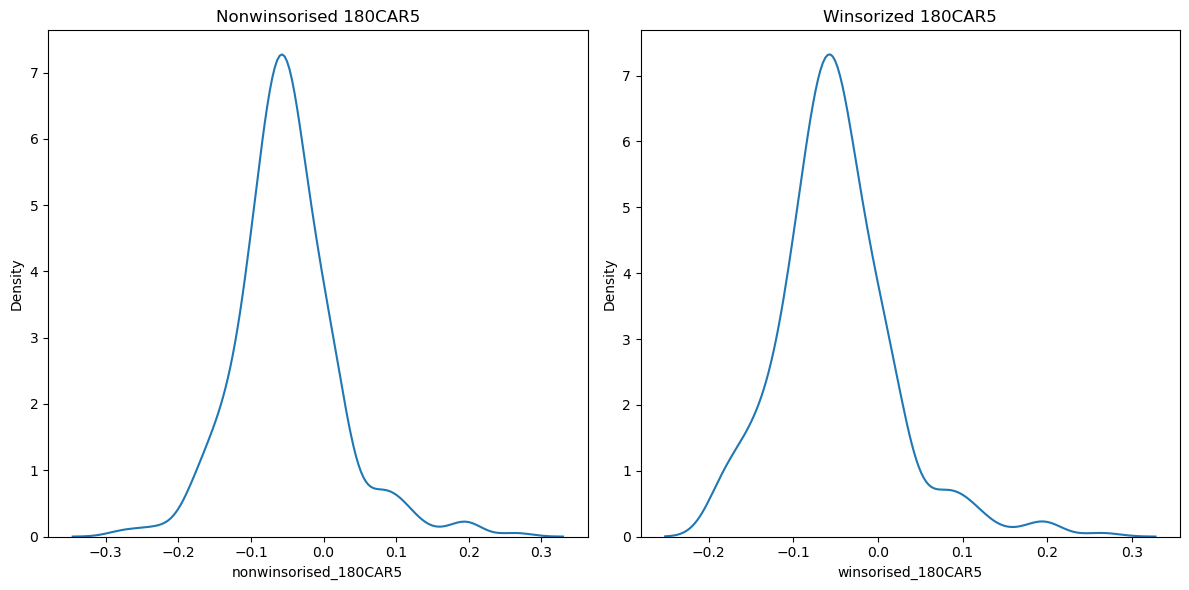

       winsorised_180CAR7  nonwinsorised_180CAR7
count          349.000000             349.000000
mean            -0.100917              -0.101834
std              0.091131               0.093570
min             -0.308891              -0.419055
25%             -0.146836              -0.146836
50%             -0.102047              -0.102047
75%             -0.058777              -0.058777
max              0.601671               0.601671


Top values and their count:  nonwinsorised_180CAR7
0.082703    1
0.086957    1
0.098750    1
0.100635    1
0.106579    1
0.112142    1
0.112928    1
0.224411    1
0.391601    1
0.601671    1
Name: count, dtype: int64





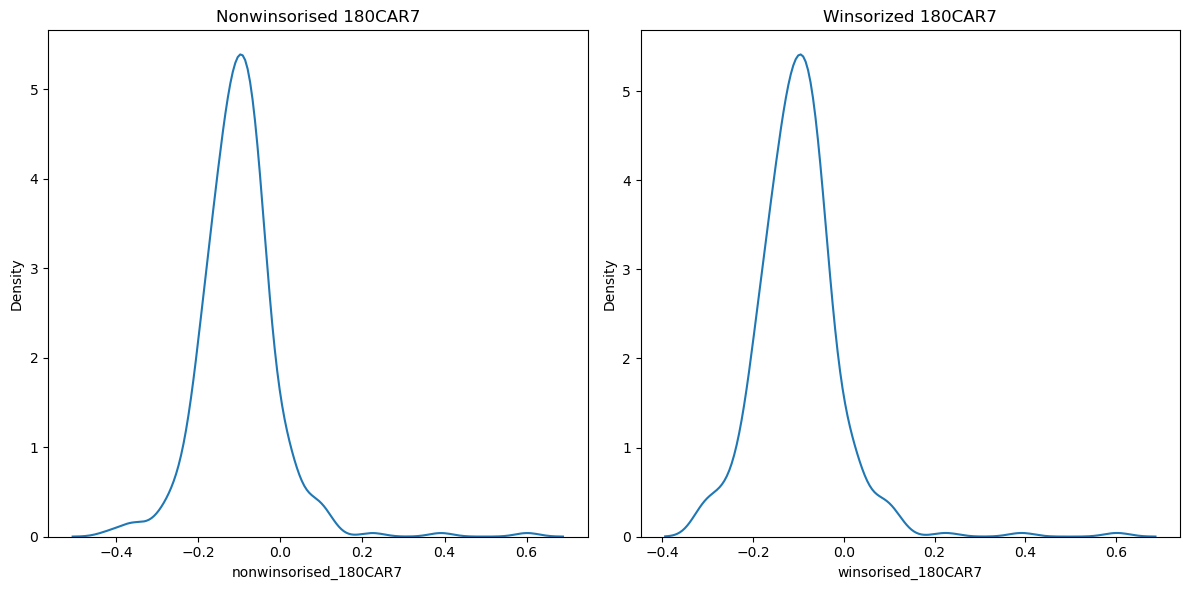

       winsorised_180CAR11  nonwinsorised_180CAR11
count           349.000000              349.000000
mean             -0.198439               -0.199343
std               0.117018                0.119700
min              -0.505573               -0.623555
25%              -0.256942               -0.256942
50%              -0.196202               -0.196202
75%              -0.132623               -0.132623
max               0.367717                0.367717


Top values and their count:  nonwinsorised_180CAR11
0.059867    1
0.066353    1
0.070520    1
0.079040    1
0.088895    1
0.094017    1
0.113194    1
0.182093    1
0.239608    1
0.367717    1
Name: count, dtype: int64





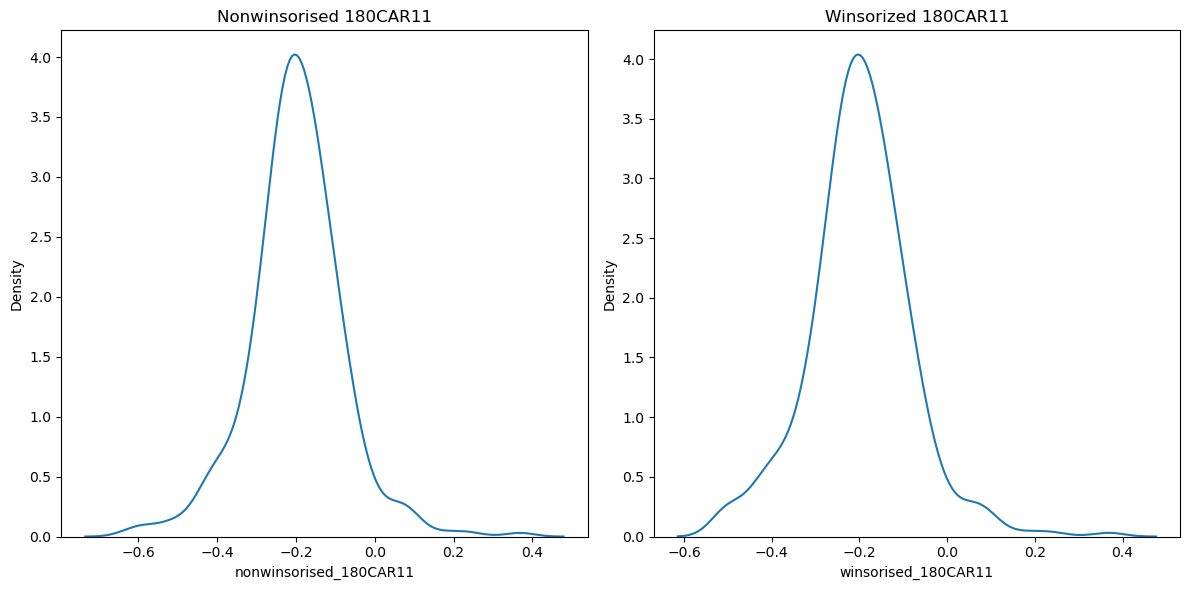

       winsorised_210CAR3  nonwinsorised_210CAR3
count          348.000000             348.000000
mean            -0.003341              -0.003899
std              0.050909               0.052514
min             -0.112610              -0.221390
25%             -0.038413              -0.038413
50%             -0.008871              -0.008871
75%              0.023297               0.023297
max              0.247487               0.247487


Top values and their count:  nonwinsorised_210CAR3
0.107924    1
0.113899    1
0.117895    1
0.134398    1
0.135469    1
0.146610    1
0.154345    1
0.163644    1
0.201650    1
0.247487    1
Name: count, dtype: int64





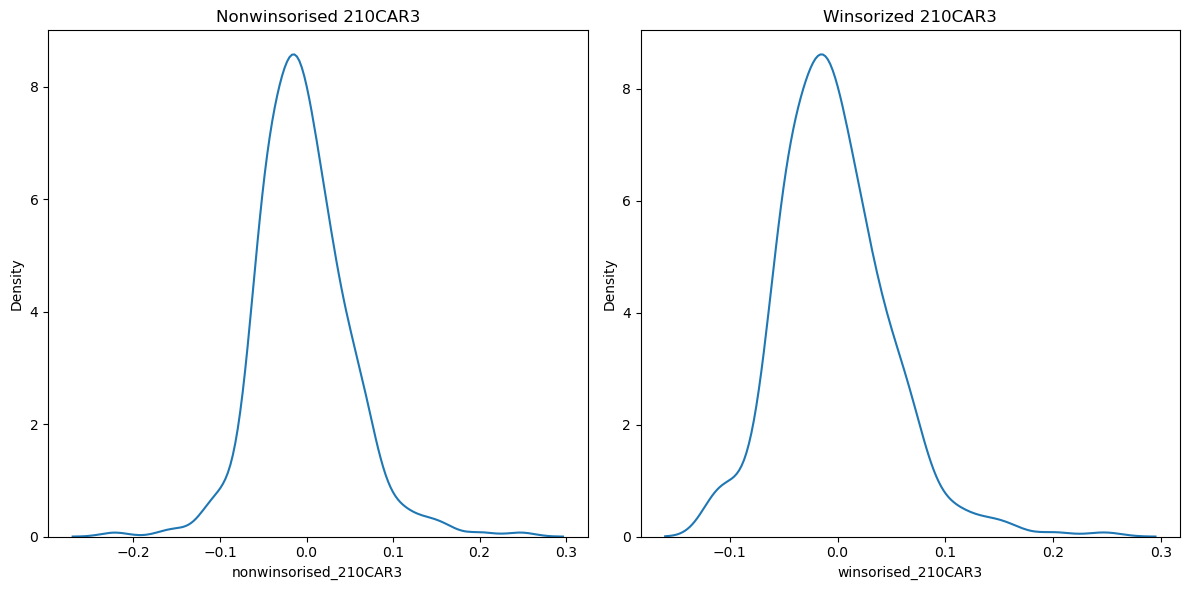

       winsorised_210CAR5  nonwinsorised_210CAR5
count          348.000000             348.000000
mean            -0.049525              -0.050220
std              0.067093               0.068863
min             -0.189676              -0.278929
25%             -0.087478              -0.087478
50%             -0.054320              -0.054320
75%             -0.018265              -0.018265
max              0.263550               0.263550


Top values and their count:  nonwinsorised_210CAR5
0.106260    1
0.106537    1
0.111594    1
0.113674    1
0.162497    1
0.182506    1
0.187549    1
0.199397    1
0.199660    1
0.263550    1
Name: count, dtype: int64





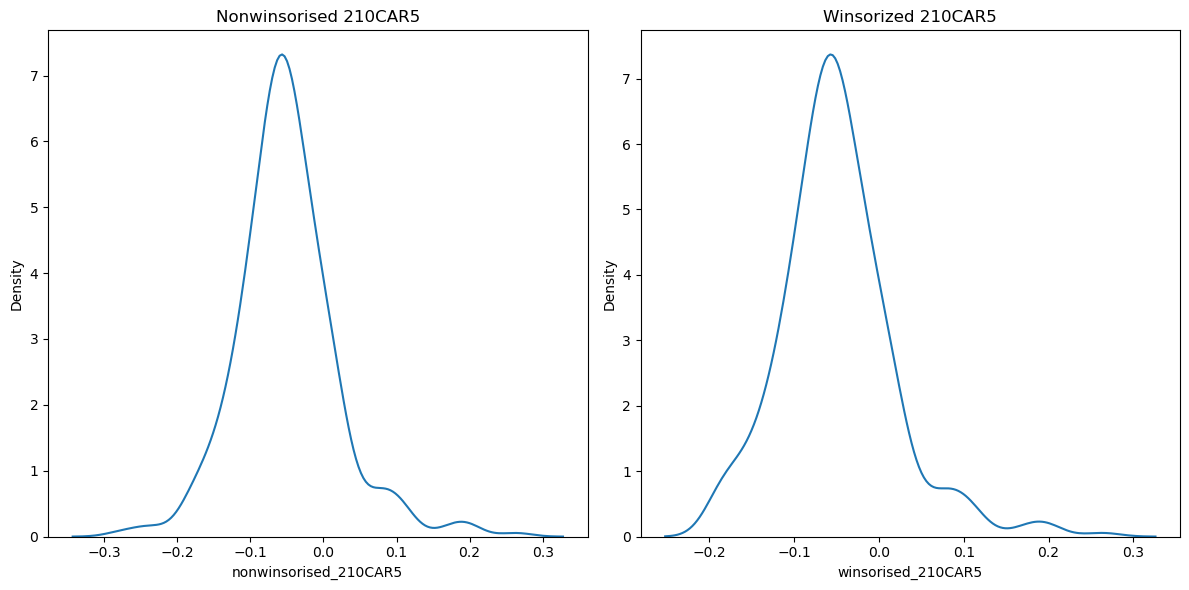

       winsorised_210CAR7  nonwinsorised_210CAR7
count          348.000000             348.000000
mean            -0.101989              -0.102861
std              0.086150               0.088576
min             -0.307967              -0.412941
25%             -0.148371              -0.148371
50%             -0.101965              -0.101965
75%             -0.056981              -0.056981
max              0.576644               0.576644


Top values and their count:  nonwinsorised_210CAR7
0.079781    1
0.083586    1
0.085948    1
0.102458    1
0.103233    1
0.105332    1
0.113342    1
0.116064    1
0.214782    1
0.576644    1
Name: count, dtype: int64





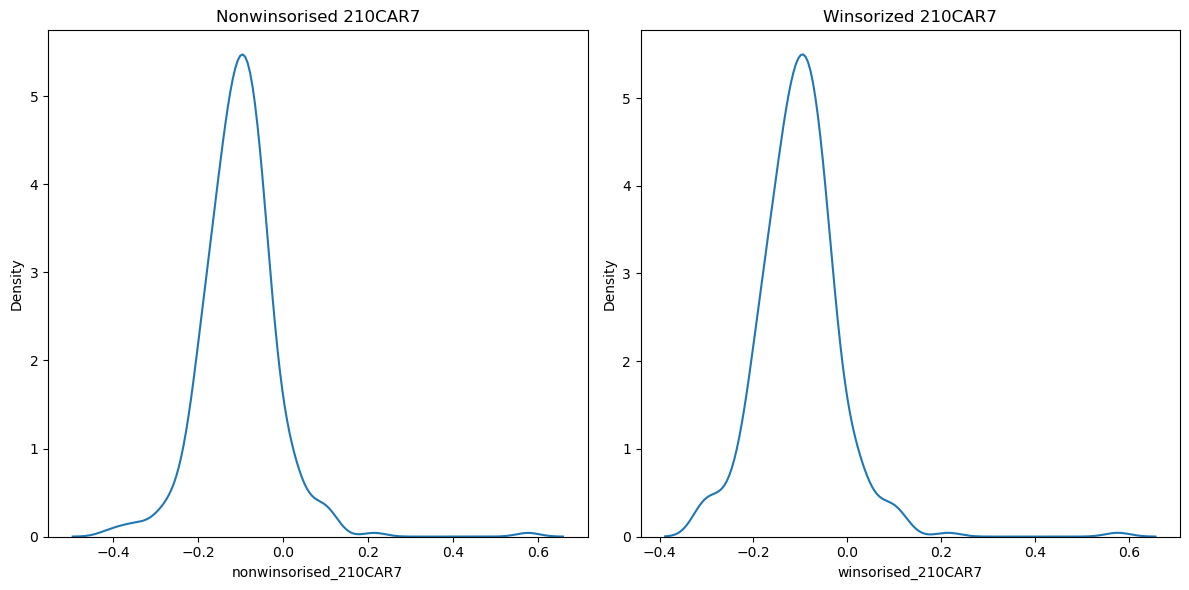

       winsorised_210CAR11  nonwinsorised_210CAR11
count           348.000000              348.000000
mean             -0.199690               -0.200640
std               0.113436                0.116308
min              -0.500934               -0.633076
25%              -0.255147               -0.255147
50%              -0.201375               -0.201375
75%              -0.133217               -0.133217
max               0.329003                0.329003


Top values and their count:  nonwinsorised_210CAR11
0.051989    1
0.056775    1
0.059850    1
0.068717    1
0.077420    1
0.087154    1
0.096631    1
0.113215    1
0.172870    1
0.329003    1
Name: count, dtype: int64





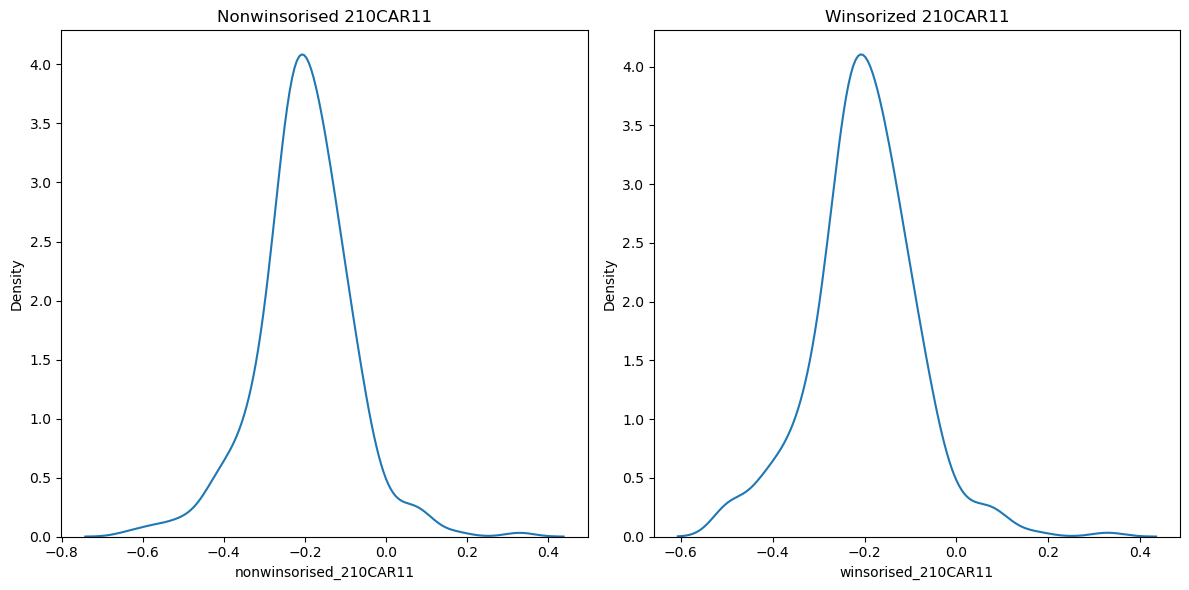

In [9]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0.01, 0.01])

In [10]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [11]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [12]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment":<20}{"Control":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [13]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [14]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [15]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [16]:
psmSampleIndep

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

# CAR Plots

### Total Sample

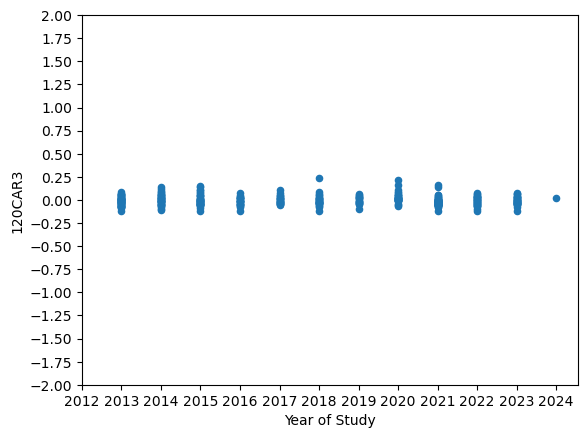

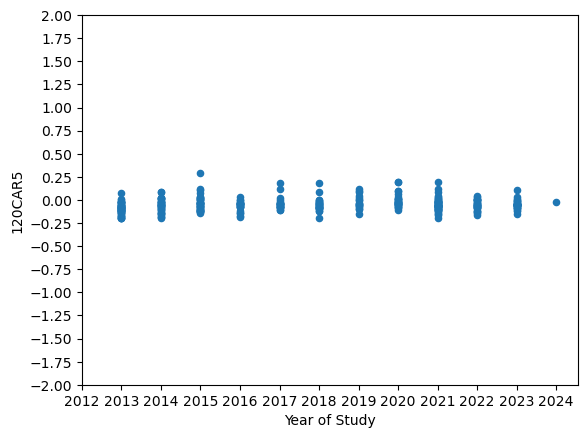

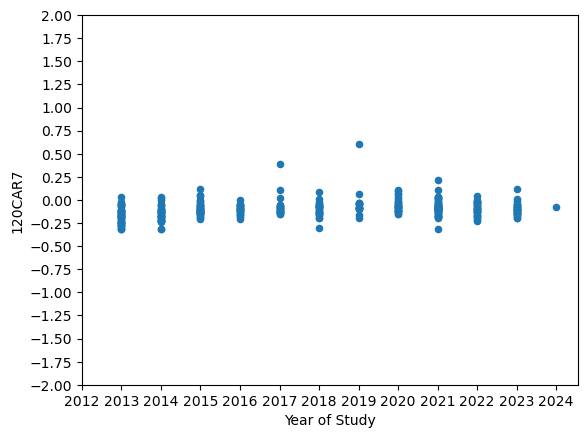

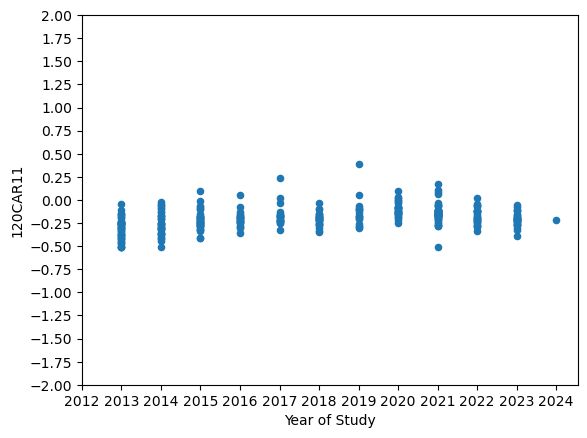

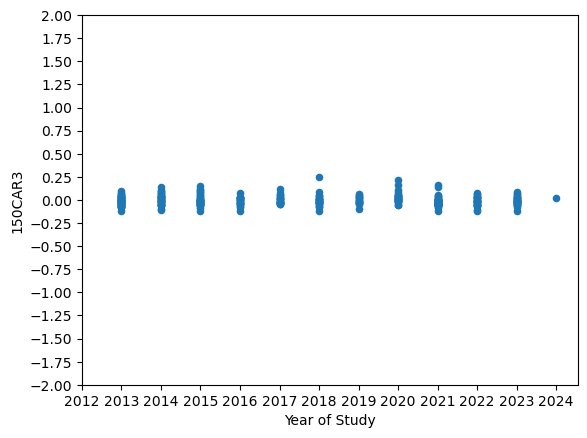

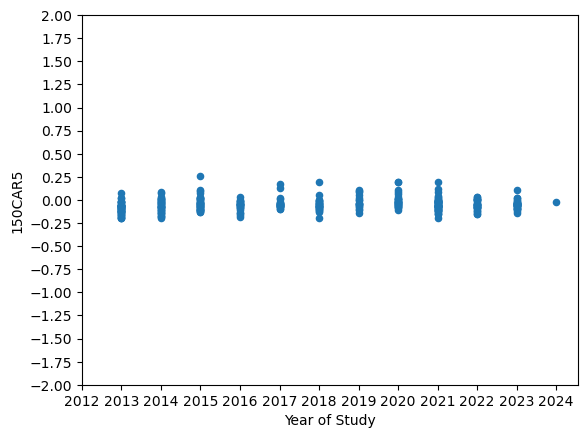

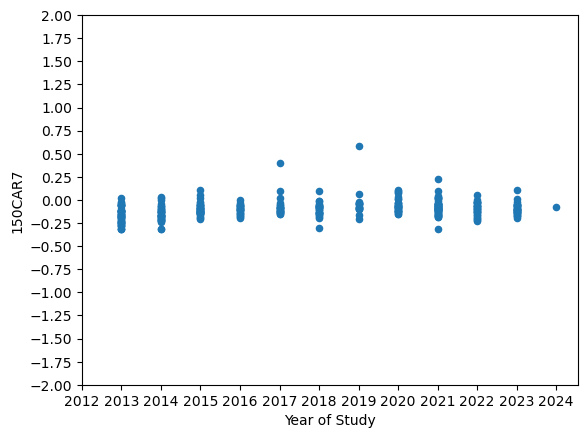

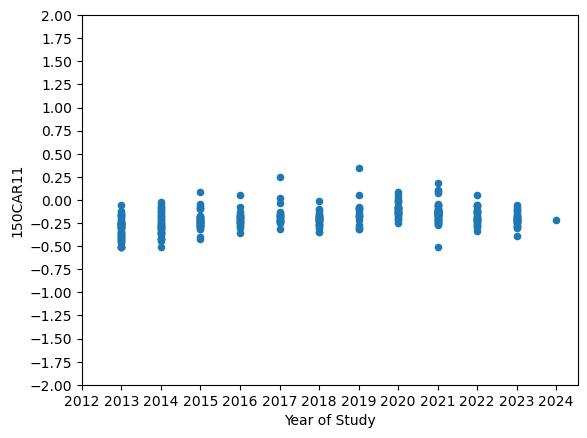

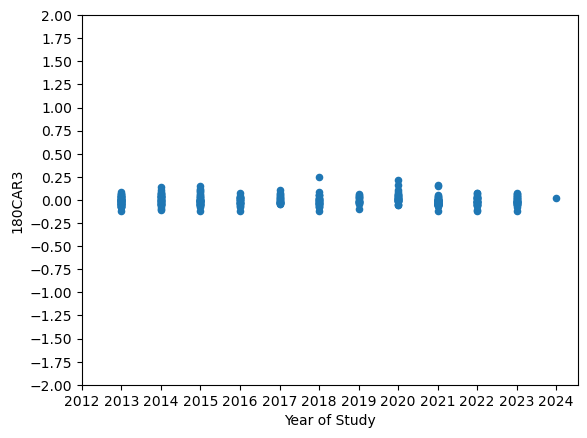

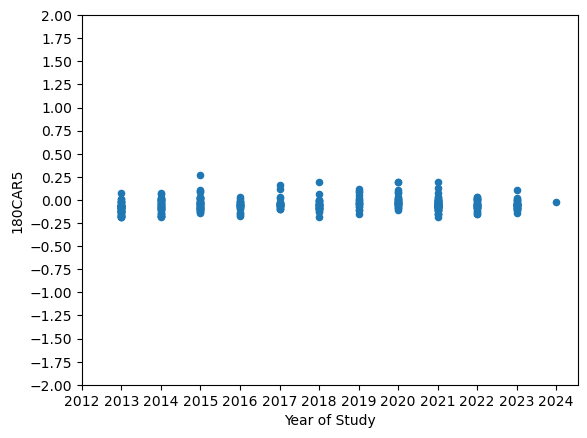

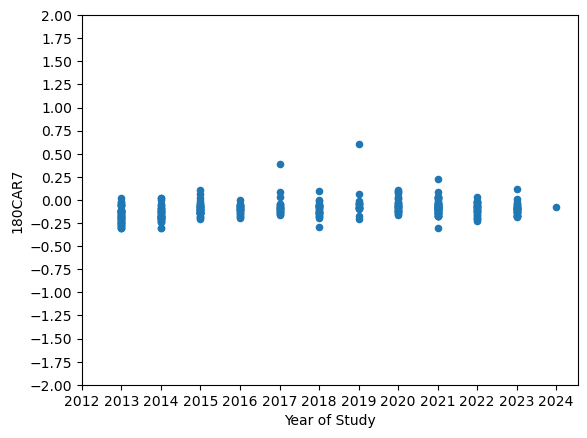

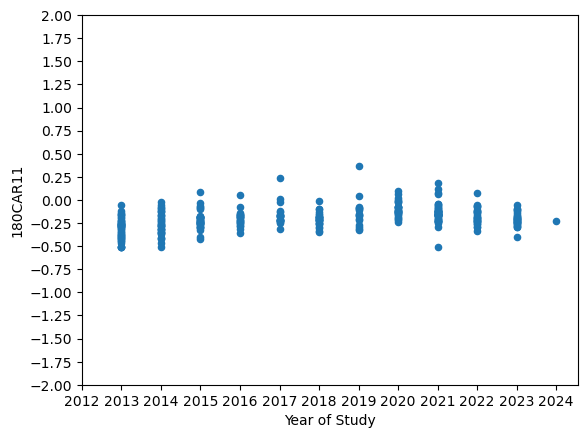

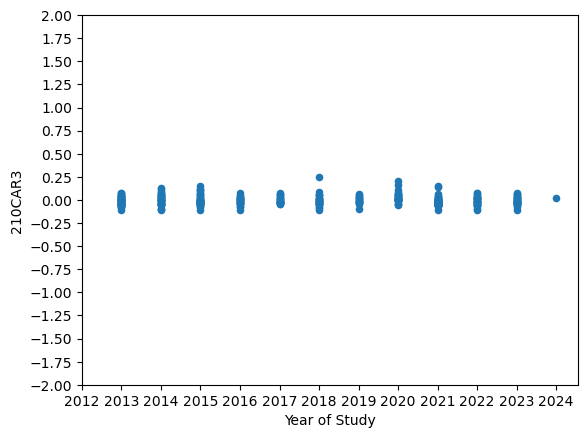

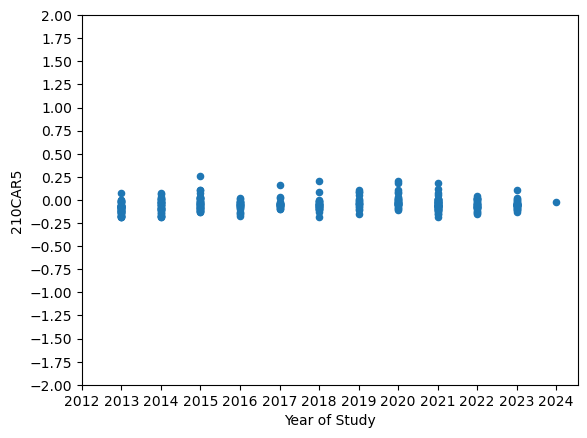

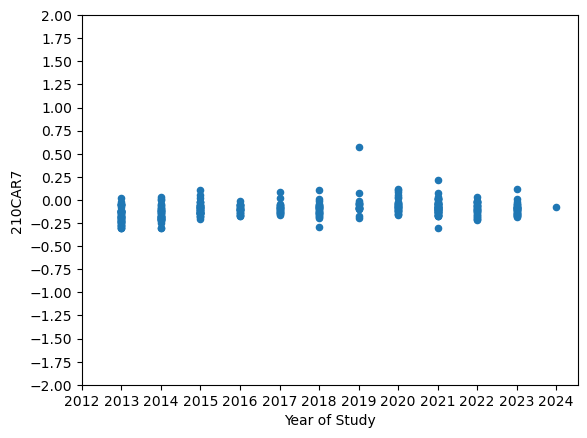

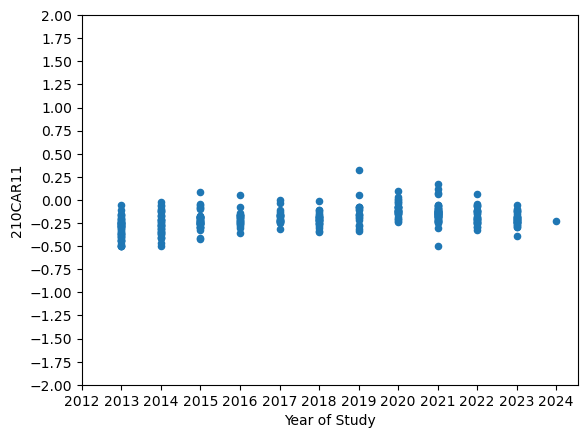

In [17]:
test = psmSampleIndep.copy()

carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

for car in carCol:
    test[car] = winsorize(test[car].values, limits = [0.01, 0.01]).data
    test[[car, "Year of Study"]].plot(kind = "scatter", x="Year of Study", y=car, xticks = np.arange(2012, 2025, step = 1), yticks = np.arange(-2, 2.25, step = 0.25))

In [18]:
test.describe()

C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\SHIVAM\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the Mask

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_SMB,OLS120_HML,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_SMB,OLS150_HML,OLS150_r_squared,OLS150_adjusted_r_squared,OLS15

### RID

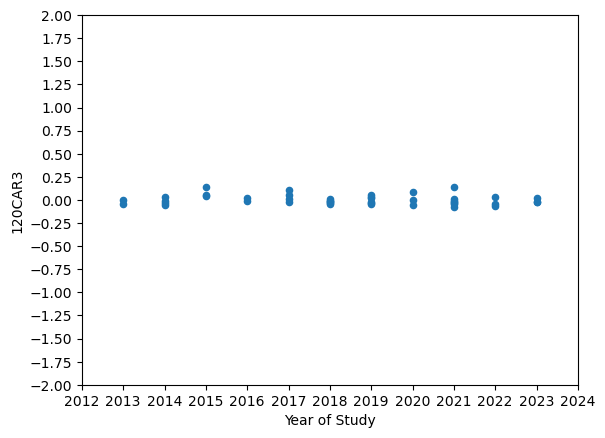

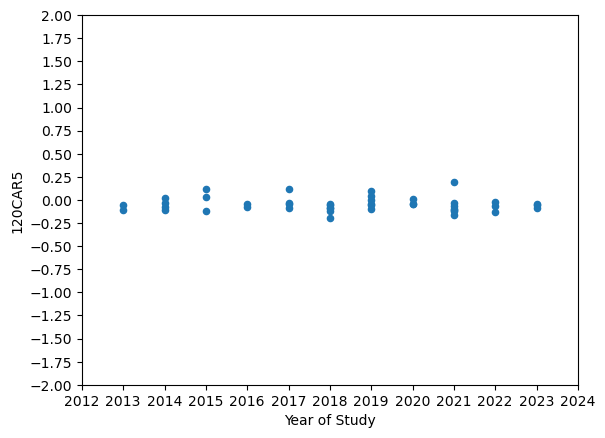

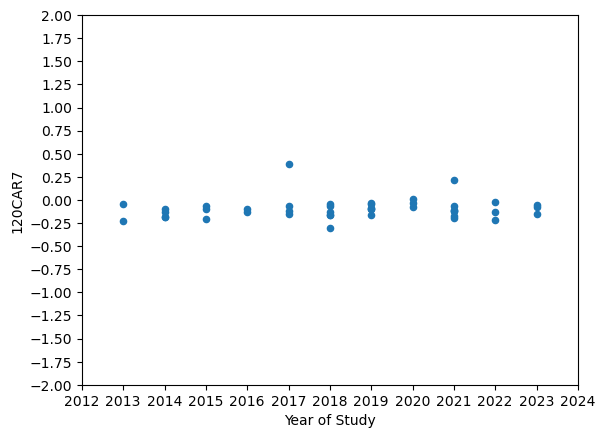

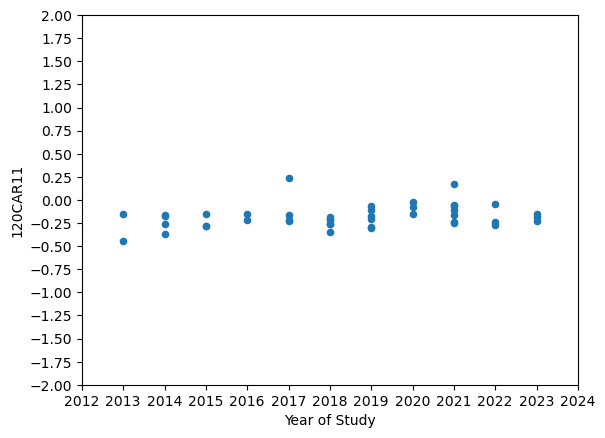

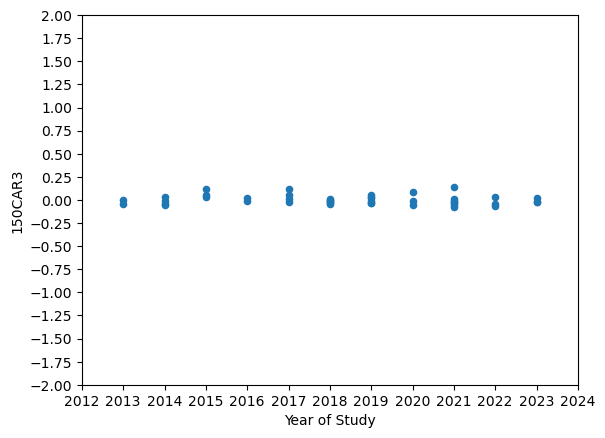

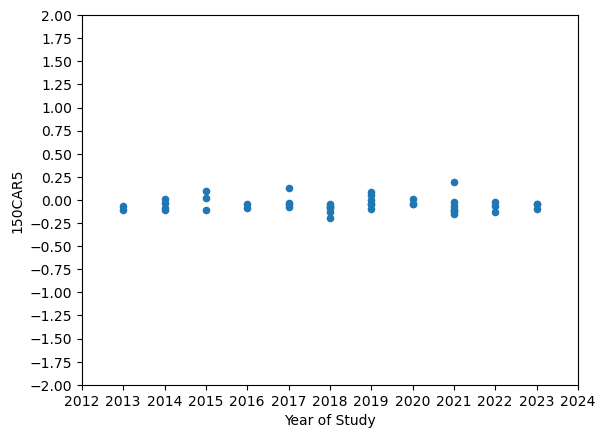

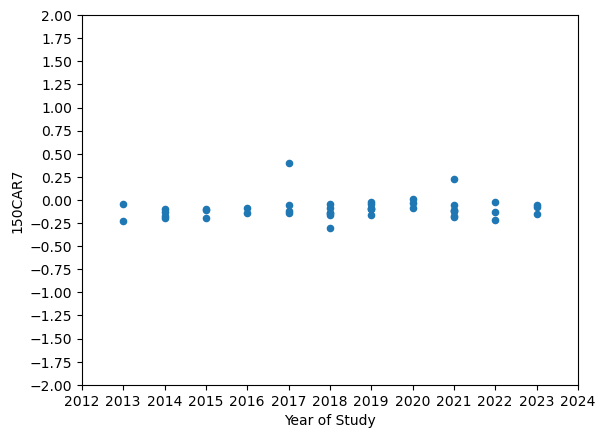

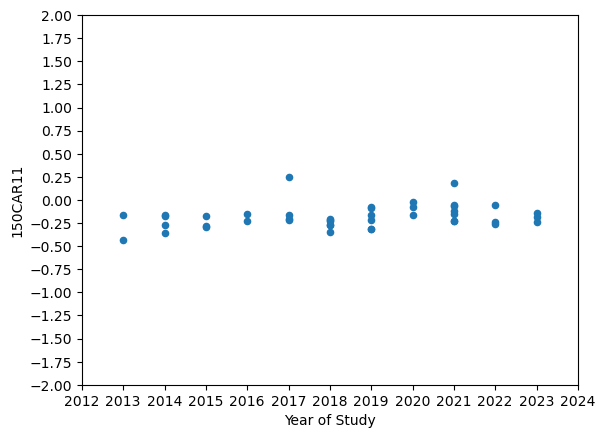

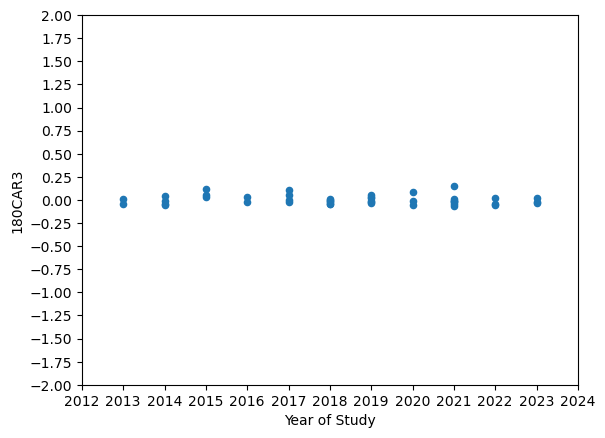

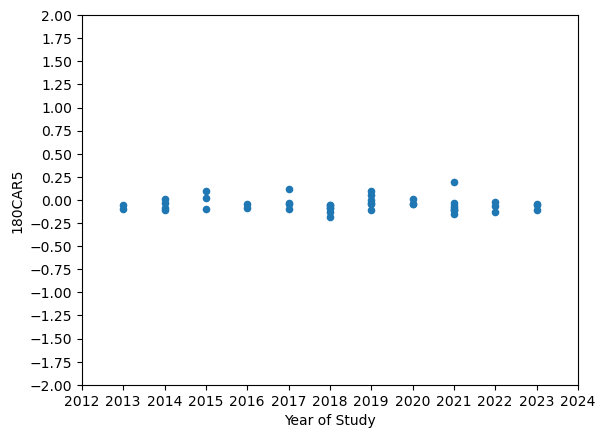

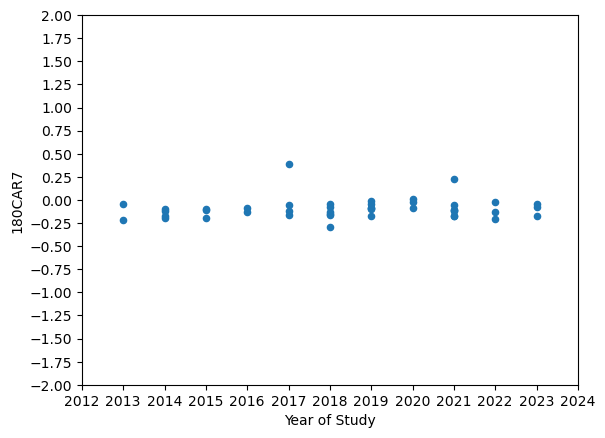

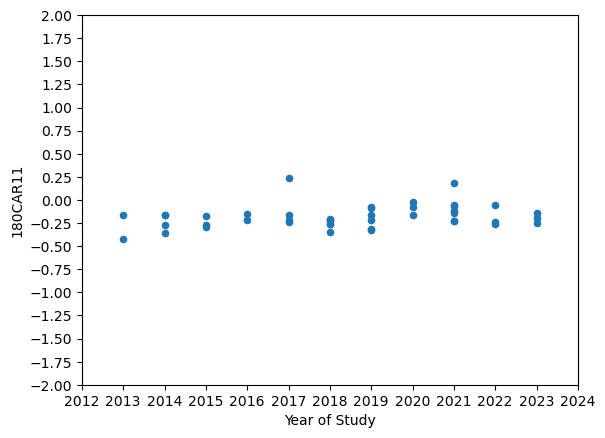

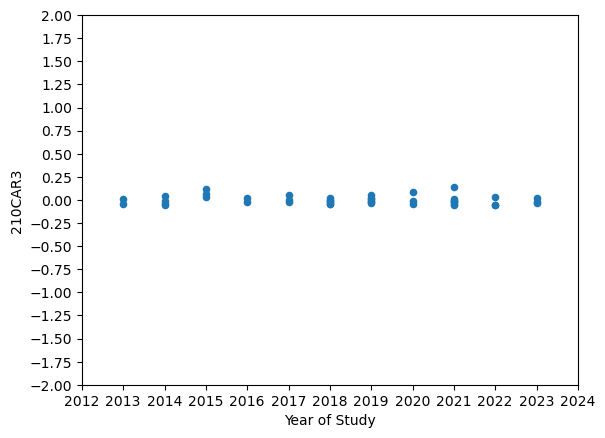

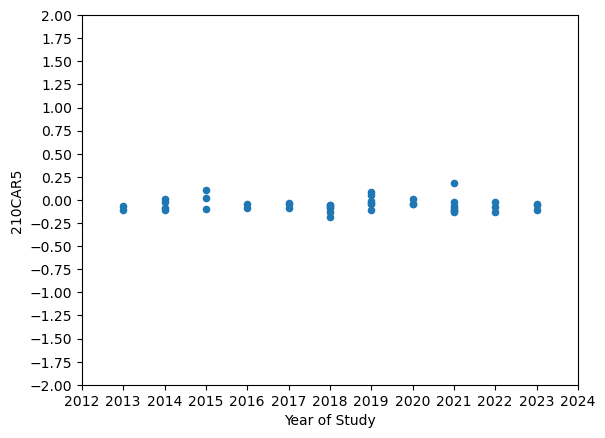

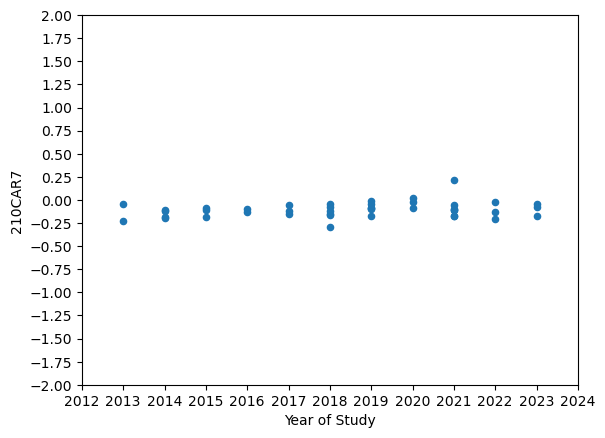

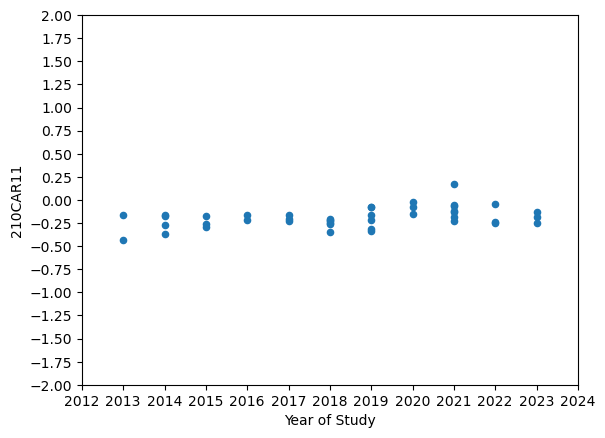

In [19]:
test = psmSampleIndep.loc[ psmSampleIndep["IsRookieIndep"] == 1 ].copy()

carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

for car in carCol:
    test[car] = winsorize(test[car].values, limits = [0.01, 0.01]).data
    test[[car, "Year of Study"]].plot(kind = "scatter", x="Year of Study", y=car, xticks = np.arange(2012, 2025, step = 1), yticks = np.arange(-2, 2.25, step = 0.25))

In [20]:
test.describe()

,index,AsOnDate,AsOnYear,Date of Birth,Tenure Valid till,Date of Demise,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,Ownership group code,Prowess company code,govtdummy,findummy,IsMBA,IsPhD,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,Manufacturing_NIC_not used,combined_sustainability,skill_committee_sustainability,combined_entrepreneurial,skill_committee_entrepreneurial,combined_compensation,skill_committee_compensation,combined_conglomerate_experience,skill_committee_conglomerate_experience,combined_hr,skill_committee_hr,combined_technology,skill_committee_technology,combined_finance_accounting,skill_committee_finance_accounting,combined_governance,skill_committee_governance,combined_government_policy,skill_committee_government_policy,combined_international,skill_committee_international,combined_leadership,skill_committee_leadership,combined_legal,skill_committee_legal,combined_marketing,skill_committee_marketing,combined_risk_management,skill_committee_risk_management,combined_scientific,skill_committee_scientific,combined_strategic_planning,skill_committee_strategic_planning,combined_manufacturing_supply_chain,skill_committee_manufacturing_supply_chain,skill_committee_leadership_outside_board,combined_leadership_outside_board,board_corporate governance,board_international business,board_industrials,board_utilities,board_finance,board_telecommunication,board_accounts/audit/taxation,board_public policy,board_risk management,board_research & development,board_legal/compliance,board_services,board_marketing,board_healthcare,board_strategy,board_commodities,board_operations,board_diversity,board_diversified,board_corporate social responsibility,board_human resources,board_fast moving consumer goods,board_economics,board_leadership/management,board_energy,board_financial services,board_information technology,board_personal values,board_consumer discretionary,board_supply chain management,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence,Date of Study,ProwessCode,ACP,pct,RF,RMRF,MF,SMB,HML,OLS120_intercept,OLS120_RMRF,OLS120_SMB,OLS120_HML,OLS120_r_squared,OLS120_adjusted_r_squared,OLS120_f_p_value,120CAR3,120CAR5,120CAR7,120CAR11,OLS150_intercept,OLS150_RMRF,OLS150_SMB,OLS150_HML,OLS150_r_squared,OLS150_adjusted_r_squared,OLS15

In [21]:
test.loc[ test["120CAR5"] >= 0.75]

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

### Non RID

In [ ]:
test = psmSampleIndep.loc[ psmSampleIndep["IsRookieIndep"] == 0 ].copy()

carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

for car in carCol:
    test[car] = winsorize(test[car].values, limits = [0.01, 0.01]).data
    test[[car, "Year of Study"]].plot(kind = "scatter", x="Year of Study", y=car, xticks = np.arange(2012, 2025, step = 1), yticks = np.arange(-2, 2.25, step = 0.25))

In [ ]:
test.describe()

In [ ]:
test.loc[ test["180CAR11"] >= 2]

## Panel A: Whole Sample

### Mean Difference

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    sample = psmSampleIndep.dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
### PSM without replacement
# PsmNonReplac(psmSampleIndep, "RookieIndepAppointDummy", controlVars, "ln_TobinQ_longborrowincl2", dirFirm)

### One Sample T Test

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    sample1 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 1].copy()
    print("Rookie Independent Directors:")
    sample = sample1.dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    sample2 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 0].copy()
    print("Non Rookie Independent Directors:")
    sample = sample2.dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)


## Panel B: Unique skills dummy

### Mean Difference: RID vs NRID

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    print("No unique skills:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("At least one unique skill:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

### Mean Difference: within RID/NRID: WIP

In [ ]:
# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# exog_var = None
# depVar = None
# controlVars = None

# for car in carCol:
#     print("No unique skills:")
#     sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
#     MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

#     print("At least one unique skill:")
#     sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
#     MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

### One Sample T Test

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

for car in carCol:
    sample1 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 1].copy()
    print("Rookie Independent Directors\nNo unique skills:")
    sample = sample1.loc[sample1["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("At least one unique skill:")
    sample = sample1.loc[sample1["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    sample2 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 0].copy()
    print("Non Rookie Independent Directors\nNo unique skills:")
    sample = sample2.loc[sample2["NumSkills_gai"] == 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("At least one unique skill:")
    sample = sample2.loc[sample2["NumSkills_gai"] != 0].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
### PSM without replacement
# PsmNonReplac(psmSampleIndep, "RookieIndepAppointDummy", controlVars, "ln_TobinQ_longborrowincl2", dirFirm)

## Panel C: Number of Skills

### Mean Difference

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

num_skills_median = psmSampleIndep.drop_duplicates(subset = ["AsOnDate", "Person Code"])["NumSkills_gai"].median()
for car in carCol:
    print("Less than median no. skills:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] < num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("Greater than median no. skills:")
    sample = psmSampleIndep.loc[psmSampleIndep["NumSkills_gai"] > num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    MeanDiffTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

### One Sample T Test

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

exog_var = None
depVar = None
controlVars = None

num_skills_median = psmSampleIndep.drop_duplicates(subset = ["AsOnDate", "Person Code"])["NumSkills_gai"].median()
for car in carCol:
    sample1 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 1].copy()
    print("Rookie Independent Directors\nLess than median no. skills:")
    sample = sample1.loc[sample1["NumSkills_gai"] < num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("Greater than median no. skills:")
    sample = sample1.loc[sample1["NumSkills_gai"] < num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    sample2 = psmSampleIndep.loc[psmSampleIndep["IsRookieIndep"] == 0].copy()
    print("Non Rookie Independent Directors\nLess than median no. skills:")
    sample = sample2.loc[sample2["NumSkills_gai"] > num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

    print("Greater than median no. skills:")
    sample = sample2.loc[sample2["NumSkills_gai"] > num_skills_median].dropna(subset = car).reset_index(drop=True).copy()
    OneSampleTtest(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
### PSM without replacement
# PsmNonReplac(psmSampleIndep, "RookieIndepAppointDummy", controlVars, "ln_TobinQ_longborrowincl2", dirFirm)